In [3]:
import os
import glob
import json

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr
from scipy.stats import f_oneway, kruskal

import stackview
from PIL import Image
from sklearn.metrics import r2_score, roc_curve, auc

from zod import ZodFrames
from zod.constants import AnnotationProject, Camera
from zod.visualization.object_visualization import overlay_object_2d_box_on_image
from zod.anno.object import Box2D

plt.style.use('default')
sns.set_palette("husl")
SEED = 43
np.random.seed(SEED)

# Load Data

In [4]:
model = "yolo"

In [5]:
base_data_path_file = f"{model}_metafeatures.csv"

iou_assessor_results = pd.read_csv("../results/assessors/iou_test_ass_" + base_data_path_file, index_col=0)
lrp_assessor_results = pd.read_csv("../results/assessors/lrp_test_ass_" + base_data_path_file, index_col=0)

print(iou_assessor_results.head(5))


   country time_of_day        lat       long road_type road_condition  \
1       PL         day  52.249511  21.043137      city         normal   
6       PL         day  52.239332  21.030383      city         normal   
39      PL         day  52.234241  21.003985      city         normal   
49      PL         day  52.224666  21.071192      city         normal   
67      PL         day  52.234931  21.007292      city         normal   

              weather  solar_angle_elevation  month  hour  ...  mean_conf  \
1   partly-cloudy-day              51.723833      4    10  ...   0.582477   
6           clear-day              42.398401      4     8  ...   0.635187   
39          clear-day              41.490165      4     8  ...   0.633618   
49  partly-cloudy-day              51.883848      4    10  ...   0.538352   
67          clear-day              41.666147      4     8  ...   0.587675   

    std_conf        GT  baseline        lr        dt        rf       mlp  \
1   0.218366  0.406334

In [6]:
dataset_root = "../data/zod"
version = "full" 
zod_frames = ZodFrames(dataset_root=dataset_root, version=version)

Loading infos: 0it [00:00, ?it/s]

In [7]:
with open(f"../results/{model}/predictions.json", "r") as f:
    preds = json.load(f)

# Assessor Performance

In [6]:
def evaluate_regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    errors = y_true - y_pred

    bin_size = 0.1
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    ece = 0.0
    N = len(y_pred)

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue

        bin_center = (bins[i - 1] + bins[i]) / 2.0
        median_obs = np.median(y_true[mask])
        ece += (mask.sum() / N) * abs(median_obs - bin_center)
        
    return {
        'r2': r2_score(y_true, y_pred),
        'mae': float(np.mean(np.abs(errors))),
        'mse': float(np.mean(errors ** 2)),
        "p95": np.quantile(np.abs(errors), 0.95),
        'ece': float(ece),              # Expected calibration error
    }


def record_regression_results(results, target, model_name, y_true, y_pred, split='test'):
    metrics = evaluate_regression_metrics(y_true, y_pred)
    split_label = split.capitalize()
    print(f"{split_label} R2 score {metrics['r2']:.4f}")
    print(f"{split_label} MAE score {metrics['mae']:.4f}")
    print(f"{split_label} MSE score {metrics['mse']:.4f}")
    print(f"{split_label} P95 score {metrics['p95']:.4f}")
    print(f"{split_label} ECE score {metrics['ece']:.4f}")
    results.append({
        'target': target,
        'model': model_name,
        f'{split}_r2': metrics['r2'],
        f'{split}_mae': metrics['mae'],
        #f'{split}_mse': metrics['mse'],
        #f'{split}_p95': metrics['p95'],
        f'{split}_ece': metrics['ece'],
    })
    return metrics

## IoU

In [7]:
model_cols = ["baseline", "lr", "dt", "rf", "mlp", "xgb", "autg"]

In [8]:
iou_metrics_rows = []
for m_col in model_cols:
    metrics = evaluate_regression_metrics(iou_assessor_results["GT"], iou_assessor_results[m_col])
    iou_metrics_rows.append({"model": m_col, **metrics})

iou_metrics = pd.DataFrame(iou_metrics_rows).sort_values("r2", ascending=False)
display(iou_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.425468,0.123825,0.026407,0.327226,0.025971
3,rf,0.416186,0.123931,0.026834,0.333507,0.030392
5,xgb,0.410345,0.124571,0.027102,0.332969,0.029704
1,lr,0.400003,0.128165,0.027578,0.332334,0.031950
2,dt,0.373029,0.128099,0.028817,0.351129,0.028902
4,mlp,0.328887,0.135345,0.030846,0.353633,0.034161
0,baseline,0.287150,0.140172,0.032765,0.368567,0.029698


## LRP

In [9]:
lrp_metrics_rows = []
for m_col in model_cols:
    metrics = evaluate_regression_metrics(lrp_assessor_results["GT"], lrp_assessor_results[m_col])
    lrp_metrics_rows.append({"model": m_col, **metrics})

lrp_metrics = pd.DataFrame(lrp_metrics_rows).sort_values("r2", ascending=False)
display(lrp_metrics)


,model,r2,mae,mse,p95,ece
6,autg,0.457167,0.102154,0.018955,0.278682,0.023567
3,rf,0.442659,0.103159,0.019461,0.285549,0.022790
5,xgb,0.435655,0.103954,0.019706,0.283473,0.026310
1,lr,0.415479,0.108473,0.020410,0.291163,0.026868
2,dt,0.412241,0.105770,0.020523,0.296628,0.023060
0,baseline,0.340246,0.116830,0.023037,0.320074,0.024932
4,mlp,0.320200,0.114637,0.023737,0.319877,0.033798


# Error analysis

In [10]:
THRESHOLD = 0.5   # Delta between predicte and expected value
TARGET_MODEL = "autg"

## IoU

In [11]:

error_df = iou_assessor_results.copy()
error_df[f"abs_delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL]).abs()
error_df[f"delta_{TARGET_MODEL}"] = (error_df["GT"] - error_df[TARGET_MODEL])
high_error = error_df[error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(high_error)}")
display(high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 38


,GT,autg,abs_delta_autg,delta_autg
21892,0.925750,0.417591,0.508159,0.508159
26117,0.923815,0.423204,0.500610,0.500610
29172,0.828591,0.313587,0.515004,0.515004
32421,0.913104,0.397291,0.515814,0.515814
32865,0.961227,0.380230,0.580997,0.580997
40289,0.878003,0.326497,0.551506,0.551506
41526,0.130505,0.643494,0.512989,-0.512989
42124,0.848091,0.188272,0.659819,0.659819
42721,0.775492,0.108136,0.667356,0.667356
43600,0.937027,0.397203,0.539825,0.539825


In [16]:
imgs_good_gt = []
id_good_gt = []
imgs_bad_gt = []
id_bad_gt = []
missing = []
for frame_id in [11534]:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and str(annotation.occlusion_level) in ["None", "Medium", "Light"] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]
    print([annotation.occlusion_level for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25])
    #annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(0, 255, 0), line_thickness=10)

    pred = preds.get(str(frame_id), {"boxes": []})
    if pred["boxes"] == []:
        pred = preds.get(f"{frame_id:06}", {"boxes": []})
        if pred["boxes"] == []:
            print(f"No predictions for frame {frame_id}")
    for i, box in enumerate(pred["boxes"]):
        if box == []:
            print(f"Missing box for frame {frame_id}, box index {i}")
        box2d = Box2D(xyxy=np.asarray(box), frame=zod_frame)
        image_with_boxes = overlay_object_2d_box_on_image(image_with_boxes, box2d, color=(255, 0, 0), line_thickness=5)


    if image_with_boxes is None:
        missing.append(frame_id)

    #if high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
    imgs_good_gt.append(image_with_boxes)
    id_good_gt.append(frame_id)
    #else: 
    #    imgs_bad_gt.append(image_with_boxes)
    #    id_bad_gt.append(frame_id)

['Light', 'Medium', 'None', 'Light', None, 'Light', 'Light']


In [9]:
print(f"Number of images: {len(imgs_good_gt) + len(imgs_bad_gt)}")
print(f"Missing images: {len(missing)} with ids: {sorted(missing)}")

Number of images: 1
Missing images: 0 with ids: []


High IoU, but assessor predicts low IoU

In [17]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt], imgs_good_gt))
stackview.switch(stack)

In [15]:
display(iou_assessor_results.loc[id_good_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
21892,FR,day,43.253578,5.382310,city,normal,clear-day,32.619982,2,13,...,0.895741,0.079673,0.925750,0.561805,0.421961,0.450193,0.422371,0.378254,0.431358,0.417591
26117,SE,day,59.258011,15.212795,city,normal,cloudy,0.180721,5,19,...,0.676497,0.230902,0.923815,0.415582,0.408558,0.376257,0.414153,0.426467,0.434351,0.423204
29172,SE,day,55.595892,12.968640,city,normal,partly-cloudy-day,44.353607,5,13,...,0.645483,0.179999,0.828591,0.394897,0.340443,0.279938,0.303529,0.309012,0.259710,0.313587
32421,FR,day,43.307082,5.431862,city,normal,clear-day,35.877271,2,12,...,0.845740,0.054112,0.913104,0.528457,0.401191,0.335794,0.359717,0.340384,0.355446,0.397291
32865,PL,day,54.380044,18.593478,city,normal,partly-cloudy-day,7.886706,6,18,...,0.918379,0.000000,0.961227,0.576903,0.457648,0.423183,0.408553,0.495035,0.432031,0.380230
40289,PL,day,51.632563,19.934583,smaller-rural,normal,cloudy,51.351186,5,9,...,0.477815,0.000000,0.878003,0.283072,0.280636,0.353732,0.260675,0.246379,0.365228,0.326497
42124,DE,night,50.108030,8.643605,city,normal,partly-cloudy-night,-31.341675,10,19,...,0.459627,0.000000,0.848091,0.270942,0.166904,0.230729,0.165965,0.204861,0.183928,0.188272
42721,DE,night,50.112190,8.643638,city,normal,partly-cloudy-night,-20.913046,10,18,...,0.316422,0.000000,0.775492,0.175432,0.047958,0.154641,0.147630,0.094174,0.147956,0.108136
43600,PL,night,54.382469,18.615574,city,normal,clear-night,-7.878422,6,20,...,0.900263,0.000000,0.937027,0.564821,0.528722,0.423183,0.395053,0.411468,0.393769,0.397203
45555,SE,day,59.877052,17.623712,city,normal,partly-cloudy-day,46.914943,6,8,...,0.769223,0.248884,0.915884,0.477425,0.399807,0.423183,0.421626,0.507043,0.465038,0.413236


IoU low, but assessor predicts high

In [33]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt], imgs_bad_gt))
stackview.switch(stack)

In [17]:
display(iou_assessor_results.loc[id_bad_gt])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
41526,IT,day,41.884419,12.611938,city,normal,clear-day,5.648459,8,17,...,0.933082,0.005265,0.130505,0.586709,0.623350,0.698091,0.725508,0.687385,0.711332,0.643494
59418,PL,day,54.357356,18.645804,arterial-urban,normal,partly-cloudy-day,57.193080,5,10,...,0.935512,0.030510,0.057551,0.588329,0.542645,0.574882,0.566888,0.493936,0.607847,0.563260
75964,FR,day,43.744620,7.379744,highway,normal,clear-day,22.832203,2,8,...,0.914913,0.000000,0.000000,0.574592,0.515699,0.507889,0.532427,0.440068,0.548763,0.559032
80278,PL,day,51.607641,19.925706,smaller-rural,normal,cloudy,51.558849,5,9,...,0.830942,0.000000,0.000000,0.518588,0.510524,0.416796,0.524279,0.647541,0.498674,0.585201
86234,IT,night,41.797536,12.535831,highway,normal,clear-night,-19.960883,8,20,...,0.894406,0.000000,0.045105,0.560915,0.649861,0.698091,0.651912,0.709194,0.629721,0.672339
86853,SE,day,64.591253,18.695283,smaller-rural,snow,fog,5.005095,1,9,...,0.859848,0.000000,0.000000,0.537867,0.584380,0.507889,0.626167,0.560290,0.706757,0.651796
86913,SE,day,63.699394,20.035110,arterial-rural,wet,snow,8.480371,3,15,...,0.885126,0.000000,0.204339,0.554725,0.705369,0.775805,0.796730,0.916503,0.817774,0.793636
90199,SE,day,62.401549,17.248207,smaller-rural,snow,partly-cloudy-night,0.582070,2,14,...,0.865122,0.000000,0.127982,0.541384,0.624644,0.507889,0.619749,0.722486,0.560248,0.630144
98787,SE,night,61.641086,14.920854,smaller-rural,snow,partly-cloudy-night,-6.272593,1,15,...,0.691356,0.000000,0.073074,0.425492,0.539543,0.554770,0.586491,0.661157,0.594689,0.612500


## LRP

In [18]:
lrp_error_df = lrp_assessor_results.copy()
lrp_error_df[f"abs_delta_{TARGET_MODEL}"] = (lrp_error_df["GT"] - lrp_error_df[TARGET_MODEL]).abs()
lrp_error_df[f"delta_{TARGET_MODEL}"] = (lrp_error_df["GT"] - lrp_error_df[TARGET_MODEL])
lrp_high_error = lrp_error_df[lrp_error_df[f"abs_delta_{TARGET_MODEL}"] > THRESHOLD]

print(f"High-error instances (|GT - {TARGET_MODEL}| > {THRESHOLD}): {len(lrp_high_error)}")
display(lrp_high_error[["GT", TARGET_MODEL, f"abs_delta_{TARGET_MODEL}", f"delta_{TARGET_MODEL}"]].head(10))

High-error instances (|GT - autg| > 0.5): 21


,GT,autg,abs_delta_autg,delta_autg
26117,0.847629,0.346255,0.501374,0.501374
27621,0.838372,0.331041,0.507331,0.507331
32865,0.922455,0.355171,0.567283,0.567283
40289,0.756006,0.180596,0.575411,0.575411
42124,0.696182,0.101431,0.594750,0.594750
43600,0.874055,0.336557,0.537498,0.537498
47059,0.885500,0.344010,0.541490,0.541490
53492,0.829076,0.235451,0.593625,0.593625
60381,0.771485,0.091455,0.680029,0.680029
69673,0.832303,0.281310,0.550993,0.550993


In [19]:
imgs_good_gt_lrp = []
id_good_gt_lrp = []
imgs_bad_gt_lrp = []
id_bad_gt_lrp = []
missing_lrp = []
for frame_id in lrp_high_error.index:
    zod_frame = zod_frames[frame_id]
    image = zod_frame.get_image() 
    annotations = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)
    annotations_2d = [annotation.box2d for annotation in annotations if annotation.name in ['Vehicle', 'Pedestrian', 'VulnerableVehicle'] and str(annotation.occlusion_level) in ["None", "Medium"] and (annotation.box2d.ymax - annotation.box2d.ymin) >= 25]

    for ann in annotations_2d:
        image_with_boxes = overlay_object_2d_box_on_image(image,ann, color=(0, 255, 0), line_thickness=10)

    pred = preds.get(str(frame_id), {"boxes": []})
    if pred["boxes"] == []:
        pred = preds.get(f"{frame_id:06}", {"boxes": []})
        if pred["boxes"] == []:
            print(f"No predictions for frame {frame_id}")
    for i, box in enumerate(pred["boxes"]):
        if box == []:
            print(f"Missing box for frame {frame_id}, box index {i}")
        box2d = Box2D(xyxy=np.asarray(box), frame=zod_frame)
        image_with_boxes = overlay_object_2d_box_on_image(image_with_boxes, box2d, color=(255, 0, 0), line_thickness=5)


    if image_with_boxes is None:
        missing_lrp.append(frame_id)

    if lrp_high_error.loc[frame_id][f"delta_{TARGET_MODEL}"] > 0:
        imgs_good_gt_lrp.append(image_with_boxes)
        id_good_gt_lrp.append(frame_id)
    else: 
        imgs_bad_gt_lrp.append(image_with_boxes)
        id_bad_gt_lrp.append(frame_id)

In [20]:
print(f"Number of images: {len(imgs_good_gt_lrp) + len(imgs_bad_gt_lrp)} with id {high_error.index}")
print(f"Missing images: {len(missing_lrp)} with ids: {sorted(missing_lrp)}")

Number of images: 21 with id Index([21892, 26117, 29172, 32421, 32865, 40289, 41526, 42124, 42721, 43600,
       45555, 47059, 49861, 53492, 55796, 57815, 59041, 59418, 60381, 69673,
       75964, 77511, 78120, 80215, 80278, 81513, 82538, 86234, 86853, 86913,
       86940, 88675, 89724, 90199, 93190, 95118, 97375, 98787],
      dtype='int64')
Missing images: 0 with ids: []


In [21]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_good_gt_lrp], imgs_good_gt_lrp))
stackview.switch(stack)

In [22]:
display(lrp_assessor_results.loc[id_good_gt_lrp])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
26117,SE,day,59.258011,15.212795,city,normal,cloudy,0.180721,5,19,...,0.676497,0.230902,0.847629,0.329856,0.325851,0.290199,0.343246,0.368272,0.396347,0.346255
27621,DE,night,49.735093,8.543191,highway,normal,partly-cloudy-night,-27.152843,10,19,...,0.728071,0.000000,0.838372,0.362065,0.362878,0.432925,0.361298,0.400933,0.321995,0.331041
32865,PL,day,54.380044,18.593478,city,normal,partly-cloudy-day,7.886706,6,18,...,0.918379,0.000000,0.922455,0.480916,0.394551,0.379943,0.379749,0.318881,0.348154,0.355171
40289,PL,day,51.632563,19.934583,smaller-rural,normal,cloudy,51.351186,5,9,...,0.477815,0.000000,0.756006,0.205775,0.222487,0.207623,0.130806,0.100965,0.194135,0.180596
42124,DE,night,50.108030,8.643605,city,normal,partly-cloudy-night,-31.341675,10,19,...,0.459627,0.000000,0.696182,0.194416,0.098705,0.134772,0.154752,0.148397,0.136981,0.101431
43600,PL,night,54.382469,18.615574,city,normal,clear-night,-7.878422,6,20,...,0.900263,0.000000,0.874055,0.469602,0.439681,0.379943,0.388767,0.376665,0.337789,0.336557
47059,DE,day,50.993509,7.032783,city,normal,clear-day,17.900075,11,11,...,0.914706,0.000000,0.885500,0.478622,0.399993,0.379943,0.404884,0.654506,0.356908,0.344010
53492,LU,day,49.674856,6.389623,highway,normal,clear-day,8.290657,3,16,...,0.523931,0.182345,0.829076,0.234575,0.259927,0.257974,0.262250,0.204456,0.217433,0.235451
60381,LU,day,49.676969,6.394069,highway,normal,clear-day,8.290657,3,16,...,0.296436,0.000000,0.771485,0.092500,0.121885,0.074959,0.071014,0.052722,0.050181,0.091455
69673,FR,day,43.743586,7.378299,highway,normal,clear-day,18.193578,2,8,...,0.769060,0.000000,0.832303,0.387664,0.337536,0.251450,0.217283,0.230020,0.200533,0.281310


In [23]:
#stack = np.stack(imgs, axis=0)
stack = dict(zip([str(i) for i in id_bad_gt_lrp], imgs_bad_gt_lrp))
stackview.switch(stack)

In [24]:
display(lrp_assessor_results.loc[id_bad_gt_lrp])

,country,time_of_day,lat,long,road_type,road_condition,weather,solar_angle_elevation,month,hour,...,mean_conf,std_conf,GT,baseline,lr,dt,rf,mlp,xgb,autg
75964,FR,day,43.744620,7.379744,highway,normal,clear-day,22.832203,2,8,...,0.914913,0.0,0.000000,0.478752,0.439348,0.468176,0.494819,0.451037,0.430014,0.509433
86234,IT,night,41.797536,12.535831,highway,normal,clear-night,-19.960883,8,20,...,0.894406,0.0,0.040210,0.465944,0.513876,0.506597,0.576268,0.634893,0.479031,0.550669
86853,SE,day,64.591253,18.695283,smaller-rural,snow,fog,5.005095,1,9,...,0.859848,0.0,0.000000,0.444362,0.494270,0.416732,0.506958,0.533793,0.515104,0.507142
86913,SE,day,63.699394,20.035110,arterial-rural,wet,snow,8.480371,3,15,...,0.885126,0.0,0.158678,0.460148,0.552750,0.680098,0.667568,0.626063,0.632977,0.667930


## Same Errors?

In [25]:
common_good_ids = set(id_good_gt).intersection(set(id_good_gt_lrp))
total_good_gt = len(set(id_good_gt).union(set(id_good_gt_lrp)))
not_common_good_ids = set(id_good_gt).symmetric_difference(set(id_good_gt_lrp))
print(f"Common good GT high-error IDs between IOU and LRP assessors: {common_good_ids}, in percentage: {len(common_good_ids)/total_good_gt*100:.2f}%")
print(f"IDS not common in good GT high-error: {not_common_good_ids} \n")

common_wrong_ids = set(id_bad_gt).intersection(set(id_bad_gt_lrp))
total_wrong_gt = len(set(id_bad_gt).union(set(id_bad_gt_lrp)))
not_common_wrong_ids = set(id_bad_gt).symmetric_difference(set(id_bad_gt_lrp))
print(f"Common wrong GT high-error IDs between IOU and LRP assessors: {common_wrong_ids}, in percentage: {len(common_wrong_ids)/total_wrong_gt*100:.2f}%")
print(f"IDS not common in wrong GT high-error: {not_common_wrong_ids}")

Common good GT high-error IDs between IOU and LRP assessors: {40289, 32865, 88675, 26117, 78120, 69673, 81513, 42124, 95118, 43600, 47059, 53492, 80215, 60381}, in percentage: 43.75%
IDS not common in good GT high-error: {21892, 49861, 93190, 77511, 57815, 86940, 97375, 72864, 42721, 59041, 27621, 32421, 82538, 96819, 55796, 45555, 29172, 89724} 

Common wrong GT high-error IDs between IOU and LRP assessors: {86913, 86234, 75964, 86853}, in percentage: 44.44%
IDS not common in wrong GT high-error: {59418, 98787, 80278, 41526, 90199}


# Regression Reliability Plots

Calibration curves but for regression. 

In [26]:
def plot_calibration_curve(y_true, y_pred, bin_size=0.1, metric: str = "IoU", ax=None, label=None, iden_line: bool = True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    avg_predicted = []
    avg_observed = []
    err_low = []
    err_high = []
    rng = np.random.default_rng(0)
    alpha = (1.0 - 0.95) / 2.0    #95% CI

    for i in range(1, len(bins)):
        mask = bin_ids == i
        if not np.any(mask):
            continue
        avg_predicted.append((bins[i - 1] + bins[i]) / 2)  # Center of bin, so it is not influenced by the data
        avg_observed.append(float(np.median(y_true[mask])))   # Mean of observed IoU

        if 300 > 0: #Bootstrap CI
            boots = np.empty(300)
            n = y_true[mask].size
            for b in range(300):
                boots[b] = np.median(rng.choice(y_true[mask], size=n, replace=True))
            lo = np.quantile(boots, alpha)
            hi = np.quantile(boots, 1.0 - alpha)
            #err_low.append(float(np.median(y_true[mask])) - lo)
            err_low.append(lo)
            #err_high.append(hi - float(np.median(y_true[mask])))
            err_high.append(hi)
        else:
            err_low.append(np.nan)
            err_high.append(np.nan)
    
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    if iden_line:
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Perfect')
    ax.plot(avg_predicted, avg_observed, marker='o', label=label or 'Model')
    ax.fill_between(avg_predicted, err_low, err_high, alpha=0.15)
    #ax.errorbar(avg_predicted,avg_observed,yerr=np.vstack([err_low, err_high]),fmt='o-',capsize=3,label=label or 'Model')
    ax.set_xlabel(f'Predicted {metric} (bin center)')
    ax.set_ylabel(f'Observed {metric} (median)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    if label is not None:
        ax.legend()
    return ax


def plot_inst_per_bin(y_pred, bin_size=0.1, ax=None, label=None, alpha=1.0, linestyle='-', fill="///", fillcolor="black"):
    y_pred = np.asarray(y_pred)
    
    bins = np.arange(0.0, 1.0 + bin_size, bin_size)
    bin_ids = np.digitize(y_pred, bins, right=False)

    n_instances = []
    bin_centers = [] 
    for i in range(1, len(bins)):
        mask = bin_ids == i
        n = np.count_nonzero(mask)
        n_instances.append(n)
        bin_centers.append((bins[i - 1] + bins[i]) / 2)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.bar(bin_centers, height=n_instances, width=bin_size, label=label or 'Model', alpha=alpha, linestyle=linestyle, hatch=fill, edgecolor='black', color=fillcolor)
    ax.set_xlabel('Bins')
    ax.set_ylabel('Nº of instances')
    if label is not None:
        ax.legend()
    return ax

## IoU

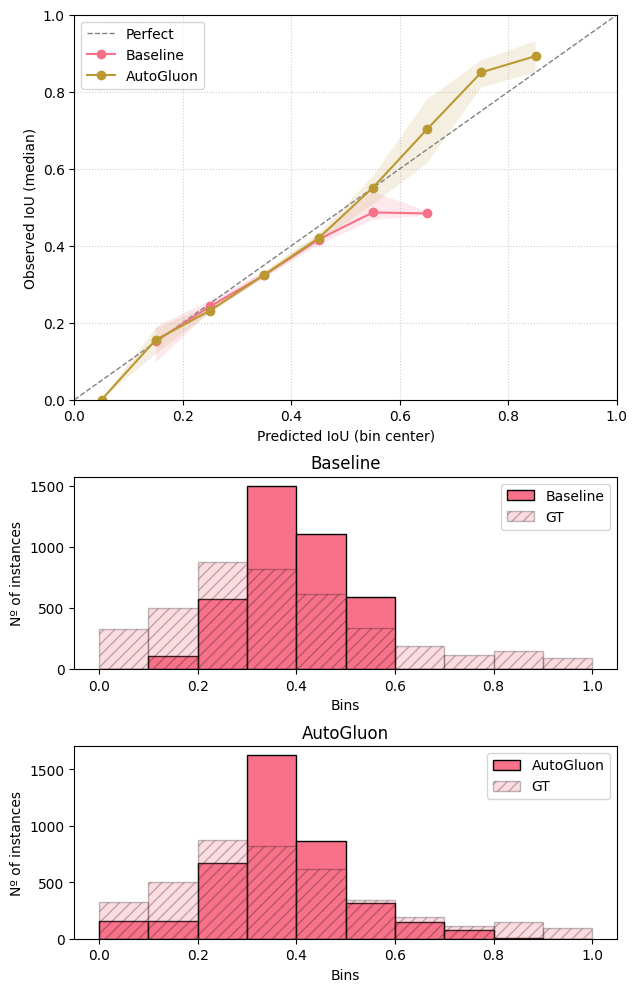

In [27]:
fig = plt.figure(figsize=(7, 12))
gs = GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.3, wspace=0.1)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["baseline"],ax=ax_cal,label="Baseline")
plot_calibration_curve(iou_assessor_results["GT"],iou_assessor_results["autg"],ax=ax_cal,label="AutoGluon", iden_line=False)
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(iou_assessor_results["baseline"], ax=ax_baseline, label="Baseline", fillcolor="C0", fill=None)
plot_inst_per_bin(iou_assessor_results["GT"], ax=ax_baseline,alpha=0.25, label="GT", fillcolor="C0", fill="///")
ax_baseline.set_title("Baseline")
ax_rf = fig.add_subplot(gs[2, 0])
plot_inst_per_bin(iou_assessor_results["autg"], ax=ax_rf, label="AutoGluon", fillcolor="C0", fill=None)
plot_inst_per_bin(iou_assessor_results["GT"], ax=ax_rf, alpha=0.25,label="GT", fillcolor="C0", fill="///")
ax_rf.set_title("AutoGluon")

plt.savefig(f"./plots/{model}_iou_baseline_vs_autog_calib_curve.svg", dpi=200, bbox_inches='tight')
plt.show()

## LRP

/tmp/ipykernel_2753623/129512201.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


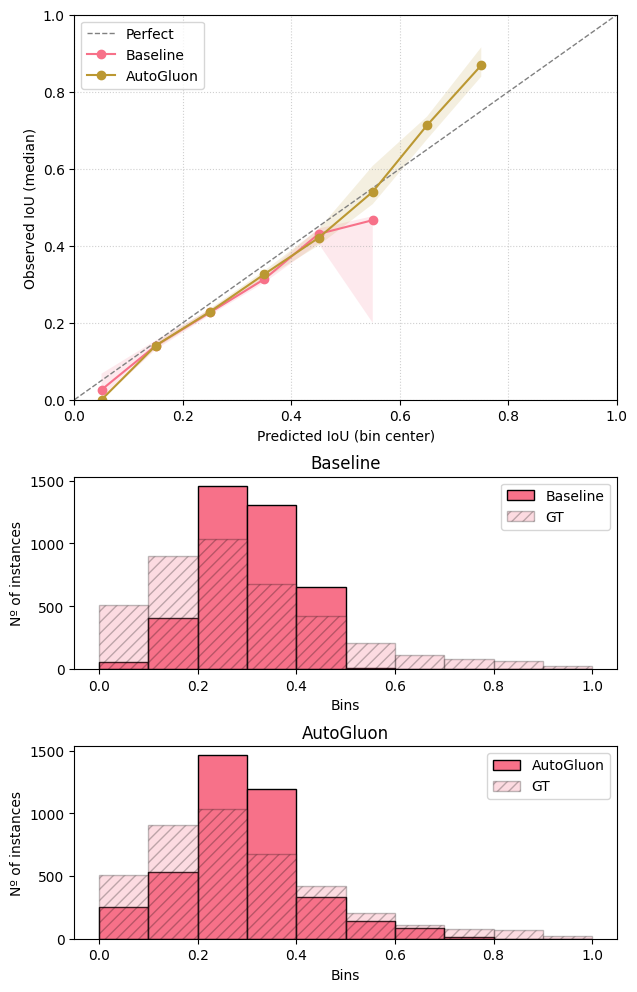

In [28]:

fig = plt.figure(figsize=(7, 12))
gs = GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.3, wspace=0.1)
ax_cal = fig.add_subplot(gs[0, :])

plot_calibration_curve(lrp_assessor_results["GT"],lrp_assessor_results["baseline"],ax=ax_cal,label="Baseline")
plot_calibration_curve(lrp_assessor_results["GT"],lrp_assessor_results["autg"],ax=ax_cal,label="AutoGluon", iden_line=False)
ax_cal.legend()

ax_baseline = fig.add_subplot(gs[1, 0])
plot_inst_per_bin(lrp_assessor_results["baseline"], ax=ax_baseline, label="Baseline", fillcolor="C0", fill=None)
plot_inst_per_bin(lrp_assessor_results["GT"], ax=ax_baseline, label="GT", alpha=0.25, fillcolor="C0", fill="///")
ax_baseline.set_title("Baseline")
ax_autg = fig.add_subplot(gs[2, 0])
plot_inst_per_bin(lrp_assessor_results["autg"], ax=ax_autg, label="AutoGluon", fillcolor="C0", fill=None)
plot_inst_per_bin(lrp_assessor_results["GT"], ax=ax_autg, label="GT", alpha=0.25, fillcolor="C0", fill="///")
ax_autg.set_title("AutoGluon")

plt.tight_layout()
plt.savefig(f"./plots/{model}_lrp_baseline_vs_autog_calib_curve.svg", dpi=200, bbox_inches='tight')
plt.show()

# AUROC

For the AUROC we need to discretize the task to binary by setting a treshold. This is not ideal as we are deleting information. So not very useful. 

In [29]:
def plot_auroc(y_true_iou, y_pred, threshold=0.5, ax=None, label=None):
    y_true_iou = np.asarray(y_true_iou)
    y_pred = np.asarray(y_pred)
    success = (y_true_iou > threshold).astype(int)

    fpr, tpr, _ = roc_curve(success, y_pred)
    roc_auc = auc(fpr, tpr)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random')
    ax.plot(fpr, tpr, label=label or f'AUROC = {roc_auc:.3f}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    return ax, roc_auc

## IoU

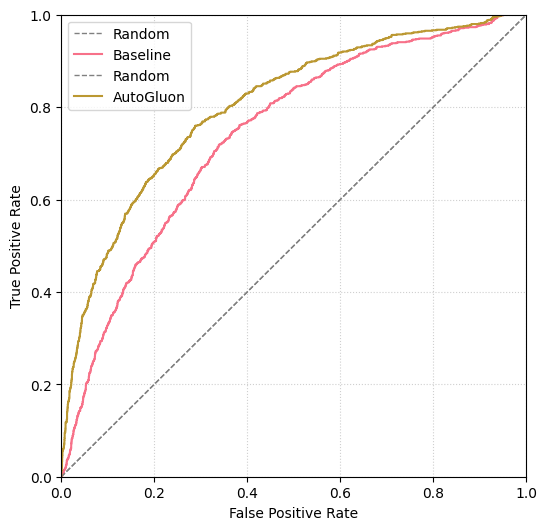

In [30]:
fig, ax = plt.subplots(figsize=(6, 6))
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["baseline"], threshold=0.5, ax=ax, label="Baseline")
_, roc_auc = plot_auroc(iou_assessor_results["GT"], iou_assessor_results["autg"], threshold=0.5, ax=ax, label="AutoGluon")
ax.legend()